# Synthetic Two-Circle Image with SimpleITK

Generate a sample image from scratch (no DICOM needed) containing **two circles**, each with a
different `int8` intensity ("color"). We then add **different noise to each region** and save both
the clean and noisy images. Every step is parameterized in the config cell below.

In [1]:
import os
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

print("SimpleITK", sitk.Version_VersionString())

SimpleITK 2.5.6


## Parameters
Edit these to change image size, the two circles (center / radius / int8 color), the per-region
noise levels, and output paths.

In [2]:
# ---- Image geometry ----
IMAGE_SIZE    = (256, 256)     # (width, height) in pixels
PIXEL_SPACING = (1.0, 1.0)     # mm per pixel
BACKGROUND    = 0              # int8 background intensity

# ---- The two circles: center (x, y), radius (px), and a distinct int8 'color' ----
CIRCLES = [
    {"name": "circle_A", "center": (85, 128),  "radius": 40, "value":  60},
    {"name": "circle_B", "center": (175, 128), "radius": 55, "value": -80},
]

# ---- Per-region Gaussian noise: (mean, std) for background and for each circle ----
NOISE = {
    "background": {"mean": 0.0, "std":  3.0},
    "circle_A":   {"mean": 0.0, "std": 15.0},
    "circle_B":   {"mean": 0.0, "std": 30.0},
}

# ---- Output ----
OUTPUT_DIR  = "output"
CLEAN_PATH  = os.path.join(OUTPUT_DIR, "two_circles_clean.nii.gz")
NOISY_PATH  = os.path.join(OUTPUT_DIR, "two_circles_noisy.nii.gz")
LABEL_PATH  = os.path.join(OUTPUT_DIR, "two_circles_labels.nii.gz")
RANDOM_SEED = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output folder:", os.path.abspath(OUTPUT_DIR))

Output folder: /Users/prahladmenon/Documents/Pitt/1340-2340--2026/Week04/output


## Build the clean image + label map
Each circle is drawn with its own `int8` value. A separate integer **label image** records which
region each pixel belongs to (0 = background, 1 = circle A, 2 = circle B) so noise can be applied
per region later.

In [3]:
def make_circle_image(size, background, circles, spacing):
    """Return (clean int8 image, int32 label image) with each circle drawn."""
    w, h = size
    yy, xx = np.mgrid[0:h, 0:w]  # row index = y, column index = x
    clean  = np.full((h, w), background, dtype=np.int16)
    labels = np.zeros((h, w), dtype=np.int32)

    for idx, c in enumerate(circles, start=1):
        cx, cy = c["center"]
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= c["radius"] ** 2
        clean[mask]  = c["value"]
        labels[mask] = idx

    clean = clean.astype(np.int8)  # final int8 'color' image

    clean_img = sitk.GetImageFromArray(clean)
    clean_img.SetSpacing(spacing)
    label_img = sitk.GetImageFromArray(labels)
    label_img.SetSpacing(spacing)
    return clean_img, label_img


clean_img, label_img = make_circle_image(IMAGE_SIZE, BACKGROUND, CIRCLES, PIXEL_SPACING)
print("clean:", clean_img.GetSize(), clean_img.GetPixelIDTypeAsString())
print("label:", label_img.GetSize(), label_img.GetPixelIDTypeAsString())

clean: (256, 256) 8-bit signed integer
label: (256, 256) 32-bit signed integer


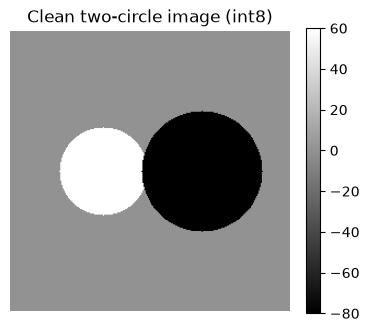

In [4]:
def show(img, title, cmap="gray"):
    arr = sitk.GetArrayViewFromImage(img)
    plt.figure(figsize=(4, 4))
    plt.imshow(arr, cmap=cmap)
    plt.title(title)
    plt.colorbar(fraction=0.046)
    plt.axis("off")
    plt.show()


show(clean_img, "Clean two-circle image (int8)")

## Add noise differently to each region
Gaussian noise with a distinct `(mean, std)` is added to the background and to each circle, using
the label map to target each region. Values are clipped back into the `int8` range.

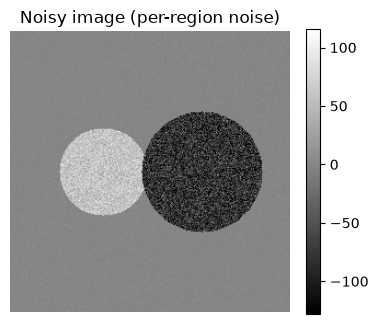

In [5]:
def add_region_noise(clean_img, label_img, circles, noise, seed=None):
    """Add Gaussian noise with a different (mean, std) per labelled region."""
    if seed is not None:
        np.random.seed(seed)

    clean  = sitk.GetArrayFromImage(clean_img).astype(np.float64)
    labels = sitk.GetArrayFromImage(label_img)
    noisy  = clean.copy()

    # background is label 0
    bg = noise["background"]
    m = labels == 0
    noisy[m] += np.random.normal(bg["mean"], bg["std"], size=int(m.sum()))

    # each circle by its label index
    for idx, c in enumerate(circles, start=1):
        p = noise[c["name"]]
        m = labels == idx
        noisy[m] += np.random.normal(p["mean"], p["std"], size=int(m.sum()))

    noisy = np.clip(noisy, -128, 127).astype(np.int8)
    noisy_img = sitk.GetImageFromArray(noisy)
    noisy_img.CopyInformation(clean_img)
    return noisy_img


noisy_img = add_region_noise(clean_img, label_img, CIRCLES, NOISE, seed=RANDOM_SEED)
show(noisy_img, "Noisy image (per-region noise)")

## Save the clean and noisy images
Written as NIfTI (`.nii.gz`); the label map is saved too for reference.

In [6]:
sitk.WriteImage(clean_img, CLEAN_PATH)
sitk.WriteImage(noisy_img, NOISY_PATH)
sitk.WriteImage(label_img, LABEL_PATH)

print("Saved:")
for p in (CLEAN_PATH, NOISY_PATH, LABEL_PATH):
    print(f"  {p}  ({os.path.getsize(p)} bytes)")

Saved:
  output/two_circles_clean.nii.gz  (648 bytes)
  output/two_circles_noisy.nii.gz  (43039 bytes)
  output/two_circles_labels.nii.gz  (1171 bytes)


# SNR and CNR analysis

We quantify image quality on the **noisy** image using the region label map
(0 = background, 1 = circle A, 2 = circle B).

**Per-region statistics** for region $r$:
- Signal $S_r = \operatorname{mean}$ of intensities in region $r$
- Noise $N_r = \operatorname{std}$ of intensities in region $r$

**Signal-to-noise ratio** (per region):
$$\mathrm{SNR}_r = \frac{|S_r|}{N_r}$$

**Contrast-to-noise ratio** (for a pair of regions $a, b$):
$$\mathrm{CNR}_{a,b} = \frac{|S_a - S_b|}{\sqrt{N_a^2 + N_b^2}}$$

We evaluate the three pairs — **circle A vs background**, **circle B vs background**,
and **circle A vs circle B** — first manually with NumPy (showing each step), then with
SimpleITK's `LabelStatisticsImageFilter`, and confirm they agree.

In [6]:
REGION_LABELS = {"background": 0, "circle_A": 1, "circle_B": 2}


def region_stats(image, label_img, region_labels):
    """Per-region mean/std (sample std, ddof=1) from an intensity image + label map."""
    arr = sitk.GetArrayFromImage(image).astype(np.float64)
    lab = sitk.GetArrayFromImage(label_img)
    stats = {}
    for name, lbl in region_labels.items():
        vals = arr[lab == lbl]
        stats[name] = {
            "label": lbl,
            "n": int(vals.size),
            "mean": float(vals.mean()),
            "std": float(vals.std(ddof=1)),
        }
    return stats


manual = region_stats(noisy_img, label_img, REGION_LABELS)

print(f"{'region':<11}{'label':>6}{'n':>8}{'mean (S)':>12}{'std (N)':>12}")
for name, s in manual.items():
    print(f"{name:<11}{s['label']:>6}{s['n']:>8}{s['mean']:>12.4f}{s['std']:>12.4f}")

region      label       n    mean (S)     std (N)
background      0   51128     -0.0017      2.6295
circle_A        1    4931     59.4766     15.1737
circle_B        2    9477    -78.3561     28.8595


In [7]:
def snr(mean, std):
    return abs(mean) / std


def cnr(s_a, s_b, n_a, n_b):
    return abs(s_a - s_b) / np.sqrt(n_a ** 2 + n_b ** 2)


# --- SNR per signal region ---
print("Per-region SNR = |S_r| / N_r")
snr_manual = {}
for name in ("circle_A", "circle_B"):
    s, n = manual[name]["mean"], manual[name]["std"]
    snr_manual[name] = snr(s, n)
    print(f"  {name}: SNR = |{s:.4f}| / {n:.4f} = {snr_manual[name]:.4f}")

# --- CNR for the three pairs, step by step ---
pairs = [("circle_A", "background"),
         ("circle_B", "background"),
         ("circle_A", "circle_B")]

print("\nPairwise CNR = |S_a - S_b| / sqrt(N_a^2 + N_b^2)")
cnr_manual = {}
for a, b in pairs:
    Sa, Na = manual[a]["mean"], manual[a]["std"]
    Sb, Nb = manual[b]["mean"], manual[b]["std"]
    diff = abs(Sa - Sb)
    denom = np.sqrt(Na ** 2 + Nb ** 2)
    cnr_manual[(a, b)] = diff / denom
    print(f"  {a} vs {b}:")
    print(f"      |{Sa:.4f} - {Sb:.4f}|            = {diff:.4f}")
    print(f"      sqrt({Na:.4f}^2 + {Nb:.4f}^2) = {denom:.4f}")
    print(f"      CNR = {cnr_manual[(a, b)]:.4f}")

Per-region SNR = |S_r| / N_r
  circle_A: SNR = |59.4766| / 15.1737 = 3.9197
  circle_B: SNR = |-78.3561| / 28.8595 = 2.7151

Pairwise CNR = |S_a - S_b| / sqrt(N_a^2 + N_b^2)
  circle_A vs background:
      |59.4766 - -0.0017|            = 59.4783
      sqrt(15.1737^2 + 2.6295^2) = 15.3999
      CNR = 3.8623
  circle_B vs background:
      |-78.3561 - -0.0017|            = 78.3544
      sqrt(28.8595^2 + 2.6295^2) = 28.9791
      CNR = 2.7038
  circle_A vs circle_B:
      |59.4766 - -78.3561|            = 137.8327
      sqrt(15.1737^2 + 28.8595^2) = 32.6054
      CNR = 4.2273


### Using SimpleITK `LabelStatisticsImageFilter`
SimpleITK computes per-label `mean` and `sigma` directly, so we can reproduce the same
SNR/CNR without manual masking and verify the two approaches agree. (ITK's `sigma` is the
sample standard deviation, matching NumPy's `std(ddof=1)`.)

In [9]:
lsif = sitk.LabelStatisticsImageFilter()
lsif.Execute(noisy_img, label_img)

sitk_stats = {}
print(f"{'region':<11}{'label':>6}{'count':>8}{'mean':>12}{'sigma':>12}")
for name, lbl in REGION_LABELS.items():
    m, sd, cnt = lsif.GetMean(lbl), lsif.GetSigma(lbl), lsif.GetCount(lbl)
    sitk_stats[name] = {"mean": m, "std": sd}
    print(f"{name:<11}{lbl:>6}{cnt:>8}{m:>12.4f}{sd:>12.4f}")

# Recompute SNR/CNR from SimpleITK stats and compare against the manual values.
print("\nSNR (SimpleITK vs manual):")
for name in ("circle_A", "circle_B"):
    v = snr(sitk_stats[name]["mean"], sitk_stats[name]["std"])
    print(f"  {name}: sitk={v:.4f}  manual={snr_manual[name]:.4f}")

print("\nCNR (SimpleITK vs manual):")
for a, b in pairs:
    v = cnr(sitk_stats[a]["mean"], sitk_stats[b]["mean"],
            sitk_stats[a]["std"], sitk_stats[b]["std"])
    print(f"  {a} vs {b}: sitk={v:.4f}  manual={cnr_manual[(a, b)]:.4f}")

region      label   count        mean       sigma
background      0   51128     -0.0017      2.6295
circle_A        1    4931     59.4766     15.1737
circle_B        2    9477    -78.3561     28.8595

SNR (SimpleITK vs manual):
  circle_A: sitk=3.9197  manual=3.9197
  circle_B: sitk=2.7151  manual=2.7151

CNR (SimpleITK vs manual):
  circle_A vs background: sitk=3.8623  manual=3.8623
  circle_B vs background: sitk=2.7038  manual=2.7038
  circle_A vs circle_B: sitk=4.2273  manual=4.2273


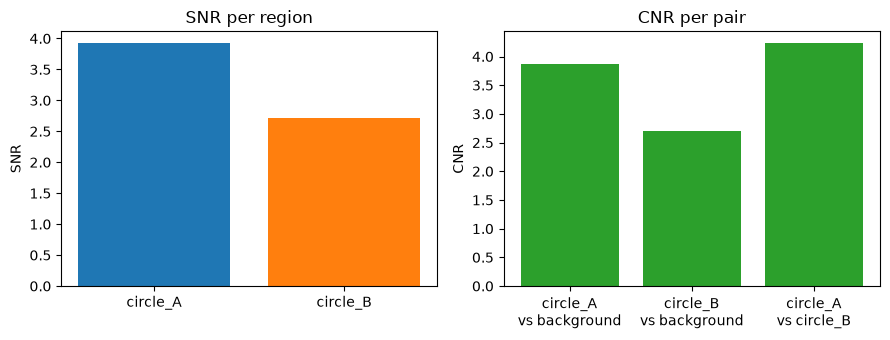

In [10]:
pair_labels = [f"{a}\nvs {b}" for a, b in pairs]
cnr_vals = [cnr_manual[p] for p in pairs]

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].bar(["circle_A", "circle_B"],
          [snr_manual["circle_A"], snr_manual["circle_B"]],
          color=["tab:blue", "tab:orange"])
ax[0].set_title("SNR per region")
ax[0].set_ylabel("SNR")
ax[1].bar(pair_labels, cnr_vals, color="tab:green")
ax[1].set_title("CNR per pair")
ax[1].set_ylabel("CNR")
plt.tight_layout()
plt.show()

# Statistical test: is the pairwise difference of means zero?

For each region pair we run **Welch's two-sample t-test** (unequal variances) on the raw pixel
intensities of the two regions.

- $H_0:\; \mu_a - \mu_b = 0$ (the two regions have the same mean intensity)
- $H_1:\; \mu_a - \mu_b \neq 0$

The test returns a **t-statistic** and a **p-value**. The t-statistic is the difference of means
divided by the *standard error* of that difference,
$$t = \frac{\bar{x}_a - \bar{x}_b}{\sqrt{s_a^2/n_a + s_b^2/n_b}},$$
which is the sample-size-aware analogue of CNR. A small p-value lets us reject $H_0$ and conclude
the contrast between the regions is statistically significant.

In [8]:
from scipy import stats


def region_pixels(image, label_img, lbl):
    """Flat array of intensities for one label."""
    arr = sitk.GetArrayFromImage(image).astype(np.float64)
    lab = sitk.GetArrayFromImage(label_img)
    return arr[lab == lbl]


alpha = 0.05
ttest_results = {}

print(f"{'pair':<26}{'t-stat':>12}{'p-value':>14}{'reject H0':>12}")
for a, b in pairs:
    xa = region_pixels(noisy_img, label_img, REGION_LABELS[a])
    xb = region_pixels(noisy_img, label_img, REGION_LABELS[b])
    res = stats.ttest_ind(xa, xb, equal_var=False)  # Welch's t-test, H0: mean_a - mean_b = 0
    ttest_results[(a, b)] = (float(res.statistic), float(res.pvalue))
    reject = "yes" if res.pvalue < alpha else "no"
    print(f"{a + ' vs ' + b:<26}{res.statistic:>12.4f}{res.pvalue:>14.3e}{reject:>12}")

pair                            t-stat       p-value   reject H0
circle_A vs background        274.8568     0.000e+00         yes
circle_B vs background       -264.1045     0.000e+00         yes
circle_A vs circle_B          375.7234     0.000e+00         yes
